<div align="center">
  <h1>Customer Churn Prediction</h1>
  <h3><i>Kaggle Playground Series - Season 6 Episode 3</i></h3>
  <hr>
</div>


### Multi-level Stacking Ridge → XGBoost + LightGBM + CatBoost + RF + KNN + SVM for Customer Churn Prediction
This notebook implements a multi-stage learning pipeline for predicting customer churn.

* **Step 1: Linear Prior (Ridge)**
In the first stage, we process the data using only Target Encoding and One-Hot Encoding to feed it into a robust **Ridge Regression** model. Ridge learns simple linear patterns in the data and generates a probability score.

* **Step 2: Advanced Complexity Hunters (The 7 Samurai)**
 The dataset prepared by Ridge is taken over by 3 different tree algorithms (XGBoost, LightGBM, CatBoost), 3 different GPU-based spatial/geometric algorithms (cuRF, cuKNN, cuSVM) and 1 tabular deep learning network (RealMLP). These models focus on learning complex, non-linear anomalies beyond the linear plane.

* **Step 3: Hill Climbing Ensemble**
Using the *Hill Climbing* algorithm, we find the optimal weight combination (weight blending) for these 7 models.

## 1. Problem Statement
Predict whether a customer will churn based on demographic information, account details and the services they subscribe to.

## 2.Pipeline Architecture

```mermaid
graph TD
    A([1. Data Loading <br> Train & Test]) --> B([2. EDA <br> Strategic Exploration])
    B --> C([3. Feature Engineering <br> Safe & Leakage-Free])
    C --> D([4. N-Gram & Encoding <br> Bi/Tri-Grams & Target Enc.])
    
    D --> E{STAGE 1: Linear Baseline}
    E --> F[Ridge Regression]
    
    F -->|Meta-Feature Injection <br> ridge_pred| G{STAGE 2: The Seven Samurai}
    
    G --> H1[XGBoost]
    G --> H2[LightGBM]
    G --> H3[CatBoost]
    G --> H4[cuML Models]
    G --> H5[RealMLP]
    
    H1 --> I{STAGE 3: Blending}
    H2 --> I
    H3 --> I
    H4 --> I
    H5 --> I
    
    I --> J((Hill Climbing Ensemble <br> AUC Optimization))
    J --> K([Final Submission])

In [1]:
!pip install catboost

In [2]:
!pip install optuna

In [3]:
# Import Libraries
import numpy as np
import pandas as pd
import warnings
import gc
import time
from itertools import combinations

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
import xgboost as xgb
from catboost import CatBoostClassifier
import lightgbm as lgb
from scipy import sparse

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
# Configuration
class CFG:
    TARGET = 'Churn'
    N_FOLDS = 20       # Outer CV folds
    INNER_FOLDS = 5    # Inner CV folds for target encoding
    RANDOM_SEED = 42
    RIDGE_ALPHA = 10.0  # L2 regularization for Ridge

    # Data paths
    TRAIN_PATH = "/kaggle/input/competitions/playground-series-s6e3/train.csv"
    TEST_PATH = "/kaggle/input/competitions/playground-series-s6e3/test.csv"

# Top categoricals for bi-gram/tri-gram combinations (by feature importance)
TOP_CATS_FOR_NGRAM = [
    'Contract', 'InternetService', 'PaymentMethod',
    'OnlineSecurity', 'TechSupport', 'PaperlessBilling'
]

# XGBoost Parameters (Optuna-optimized)
XGB_PARAMS = {
    'n_estimators': 50000,
    'learning_rate': 0.0063,
    'max_depth': 5,
    'subsample': 0.81,
    'colsample_bytree': 0.32,
    'min_child_weight': 6,
    'reg_alpha': 3.5017,
    'reg_lambda': 1.2925,
    'gamma': 0.790,
    'random_state': CFG.RANDOM_SEED,
    'early_stopping_rounds': 500,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'enable_categorical': True,
    'tree_method':'hist',
    'device': 'cuda',
    'verbosity': 0,
}

# LightGBM Parameters 
LGB_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'random_state': CFG.RANDOM_SEED,
    'verbose': -1,
    'n_estimators': 1500,
    'device_type': 'gpu', 
    
    'learning_rate': 0.026895503004610237,
    'max_depth': 8,
    'num_leaves': 30,
    'min_child_samples': 100,
    'subsample': 0.9110729138790491,        
    'colsample_bytree': 0.6651876137569497, 
    'reg_alpha': 0.07199891815558833,
    'reg_lambda': 0.005102671104374717
}

# CatBoost Parameters 
CAT_PARAMS = {
    'iterations': 1500,
    'eval_metric': 'AUC',
    'random_seed': CFG.RANDOM_SEED,
    'task_type': 'GPU', 
    'verbose': False,
    
    'learning_rate': 0.012050673809901529,
    'depth': 8,
    'l2_leaf_reg': 16.23048246524537,
    'random_strength': 5.8447438740112565,
    'border_count': 216
}

# MLP Hyperparameters
BATCH_SIZE = 1024
EPOCHS = 100
PATIENCE = 10 

print("Configuration set!")
print(f"  N_FOLDS: {CFG.N_FOLDS}")
print(f"  RIDGE_ALPHA: {CFG.RIDGE_ALPHA}")

Configuration set!
  N_FOLDS: 20
  RIDGE_ALPHA: 10.0


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device used: {device}")

# The RealMLP Architecture for Tabular Data
class RealMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], dropout_rate=0.2):
        super().__init__()
        layers = []
        in_dim = input_dim

        for h_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(nn.LayerNorm(h_dim)) 
            layers.append(nn.GELU())           
            layers.append(nn.Dropout(dropout_rate))
            in_dim = h_dim

        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1) 


Device used: cuda


In [6]:
# Load Data
print("Loading datasets (ORİJİNAL VERİ İPTAL EDİLDİ)...")
train = pd.read_csv(CFG.TRAIN_PATH)
test = pd.read_csv(CFG.TEST_PATH)

# Encode target variable
train[CFG.TARGET] = train[CFG.TARGET].map({'No': 0, 'Yes': 1}).astype(int)

# Store IDs for later
train_ids = train['id'].copy()
test_ids = test['id'].copy()

print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")

Loading datasets (ORİJİNAL VERİ İPTAL EDİLDİ)...
Train Shape : (594194, 21)
Test Shape  : (254655, 20)


## 3.Exploratory Data Analysis (EDA)

In [7]:
# Dataset Overview
print("="*60)
print("TRAINING DATA OVERVIEW")
print("="*60)
display(train.head())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
print(train.dtypes.to_frame('dtype'))

TRAINING DATA OVERVIEW


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1



DATA TYPES
                    dtype
id                  int64
gender             object
SeniorCitizen       int64
Partner            object
Dependents         object
tenure              int64
PhoneService       object
MultipleLines      object
InternetService    object
OnlineSecurity     object
OnlineBackup       object
DeviceProtection   object
TechSupport        object
StreamingTV        object
StreamingMovies    object
Contract           object
PaperlessBilling   object
PaymentMethod      object
MonthlyCharges    float64
TotalCharges      float64
Churn               int64


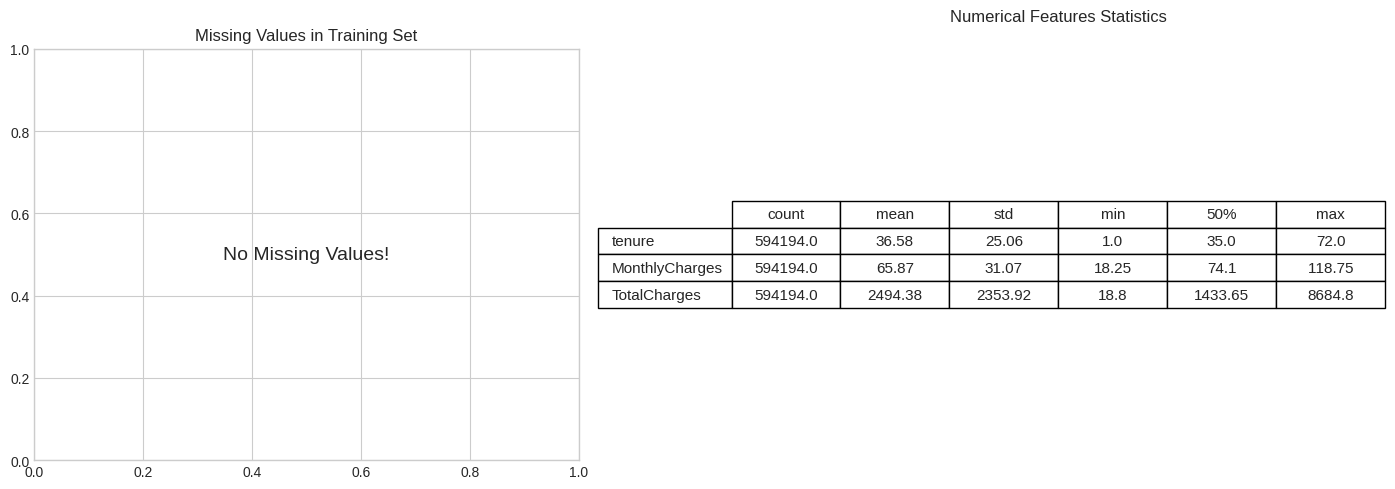

In [8]:
# Missing Values Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set missing values
train_missing = train.isnull().sum()
train_missing = train_missing[train_missing > 0]
if len(train_missing) > 0:
    axes[0].barh(train_missing.index, train_missing.values, color='coral')
    axes[0].set_xlabel('Missing Count')
    axes[0].set_title('Missing Values in Training Set')
else:
    axes[0].text(0.5, 0.5, 'No Missing Values!', ha='center', va='center', fontsize=14)
    axes[0].set_title('Missing Values in Training Set')

# Numerical statistics
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
stats_df = train[num_cols].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
axes[1].axis('off')
table = axes[1].table(cellText=stats_df.round(2).values,
                       rowLabels=stats_df.index,
                       colLabels=stats_df.columns,
                       cellLoc='center',
                       loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
axes[1].set_title('Numerical Features Statistics', fontsize=12, pad=20)

plt.tight_layout()
plt.show()

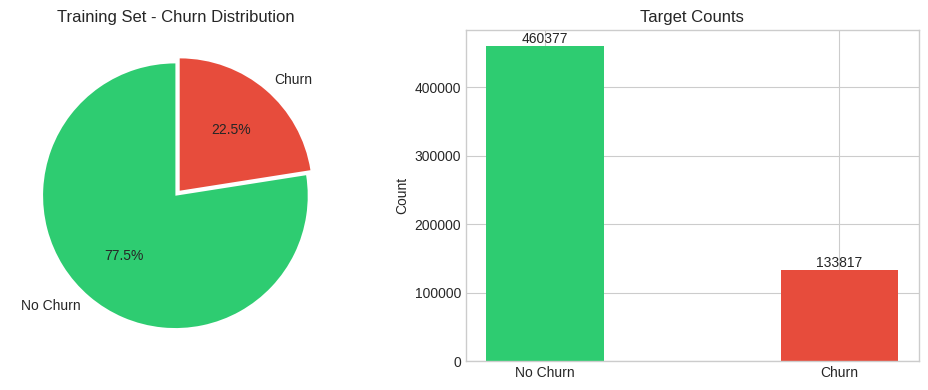


Churn Rate - Training: 22.52%


In [9]:
# Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Training set target - Pie Chart
train_churn = train[CFG.TARGET].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(train_churn.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=colors, explode=[0, 0.05], startangle=90)
axes[0].set_title('Training Set - Churn Distribution')

# Training set target - Bar Chart
bars = axes[1].bar(['No Churn', 'Churn'], train_churn.values, color=colors, width=0.4)
axes[1].set_ylabel('Count')
axes[1].set_title('Target Counts')

# Bar grafiğinin üzerine sayıları yazma
for bar in bars:
    height = bar.get_height()
    axes[1].annotate(f'{int(height)}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nChurn Rate - Training: {train[CFG.TARGET].mean()*100:.2f}%")

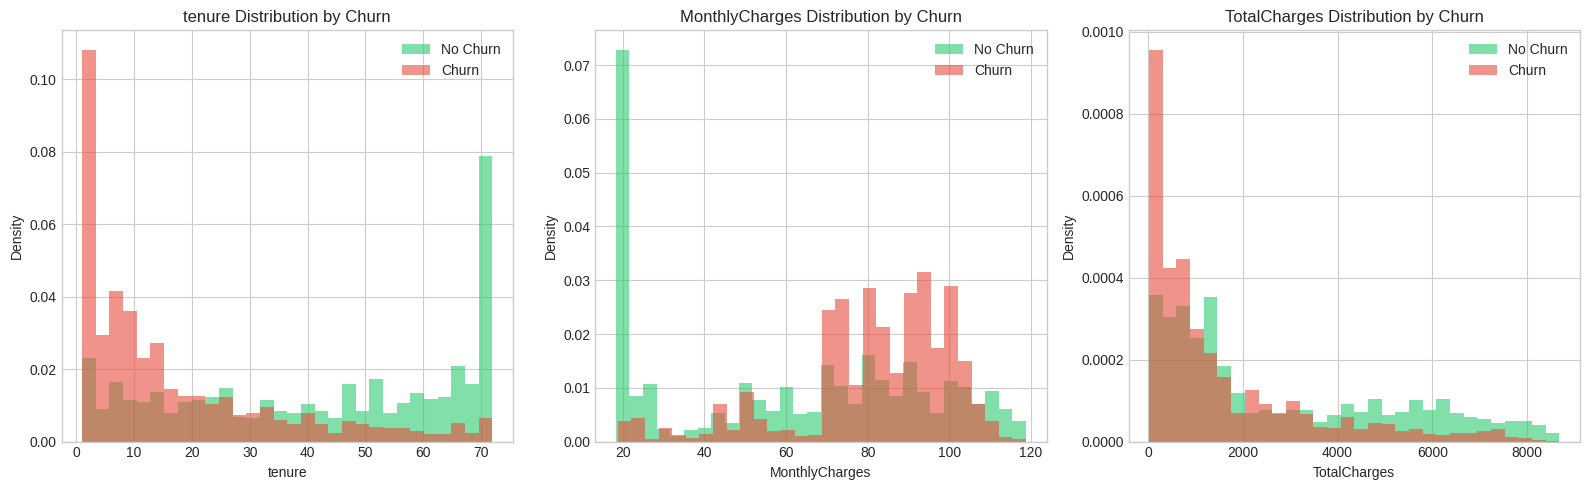


Key Observations:
  - Tenure: Churners tend to have shorter tenure
  - MonthlyCharges: Churners often have higher monthly charges
  - TotalCharges: Churners typically have lower total charges (correlated with tenure)


In [10]:
# Numerical Features Distribution by Churn
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    for churn_val, label, color in [(0, 'No Churn', '#2ecc71'), (1, 'Churn', '#e74c3c')]:
        data = train[train[CFG.TARGET] == churn_val][col]
        axes[idx].hist(data, bins=30, alpha=0.6, label=label, color=color, density=True)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density')
    axes[idx].set_title(f'{col} Distribution by Churn')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("  - Tenure: Churners tend to have shorter tenure")
print("  - MonthlyCharges: Churners often have higher monthly charges")
print("  - TotalCharges: Churners typically have lower total charges (correlated with tenure)")

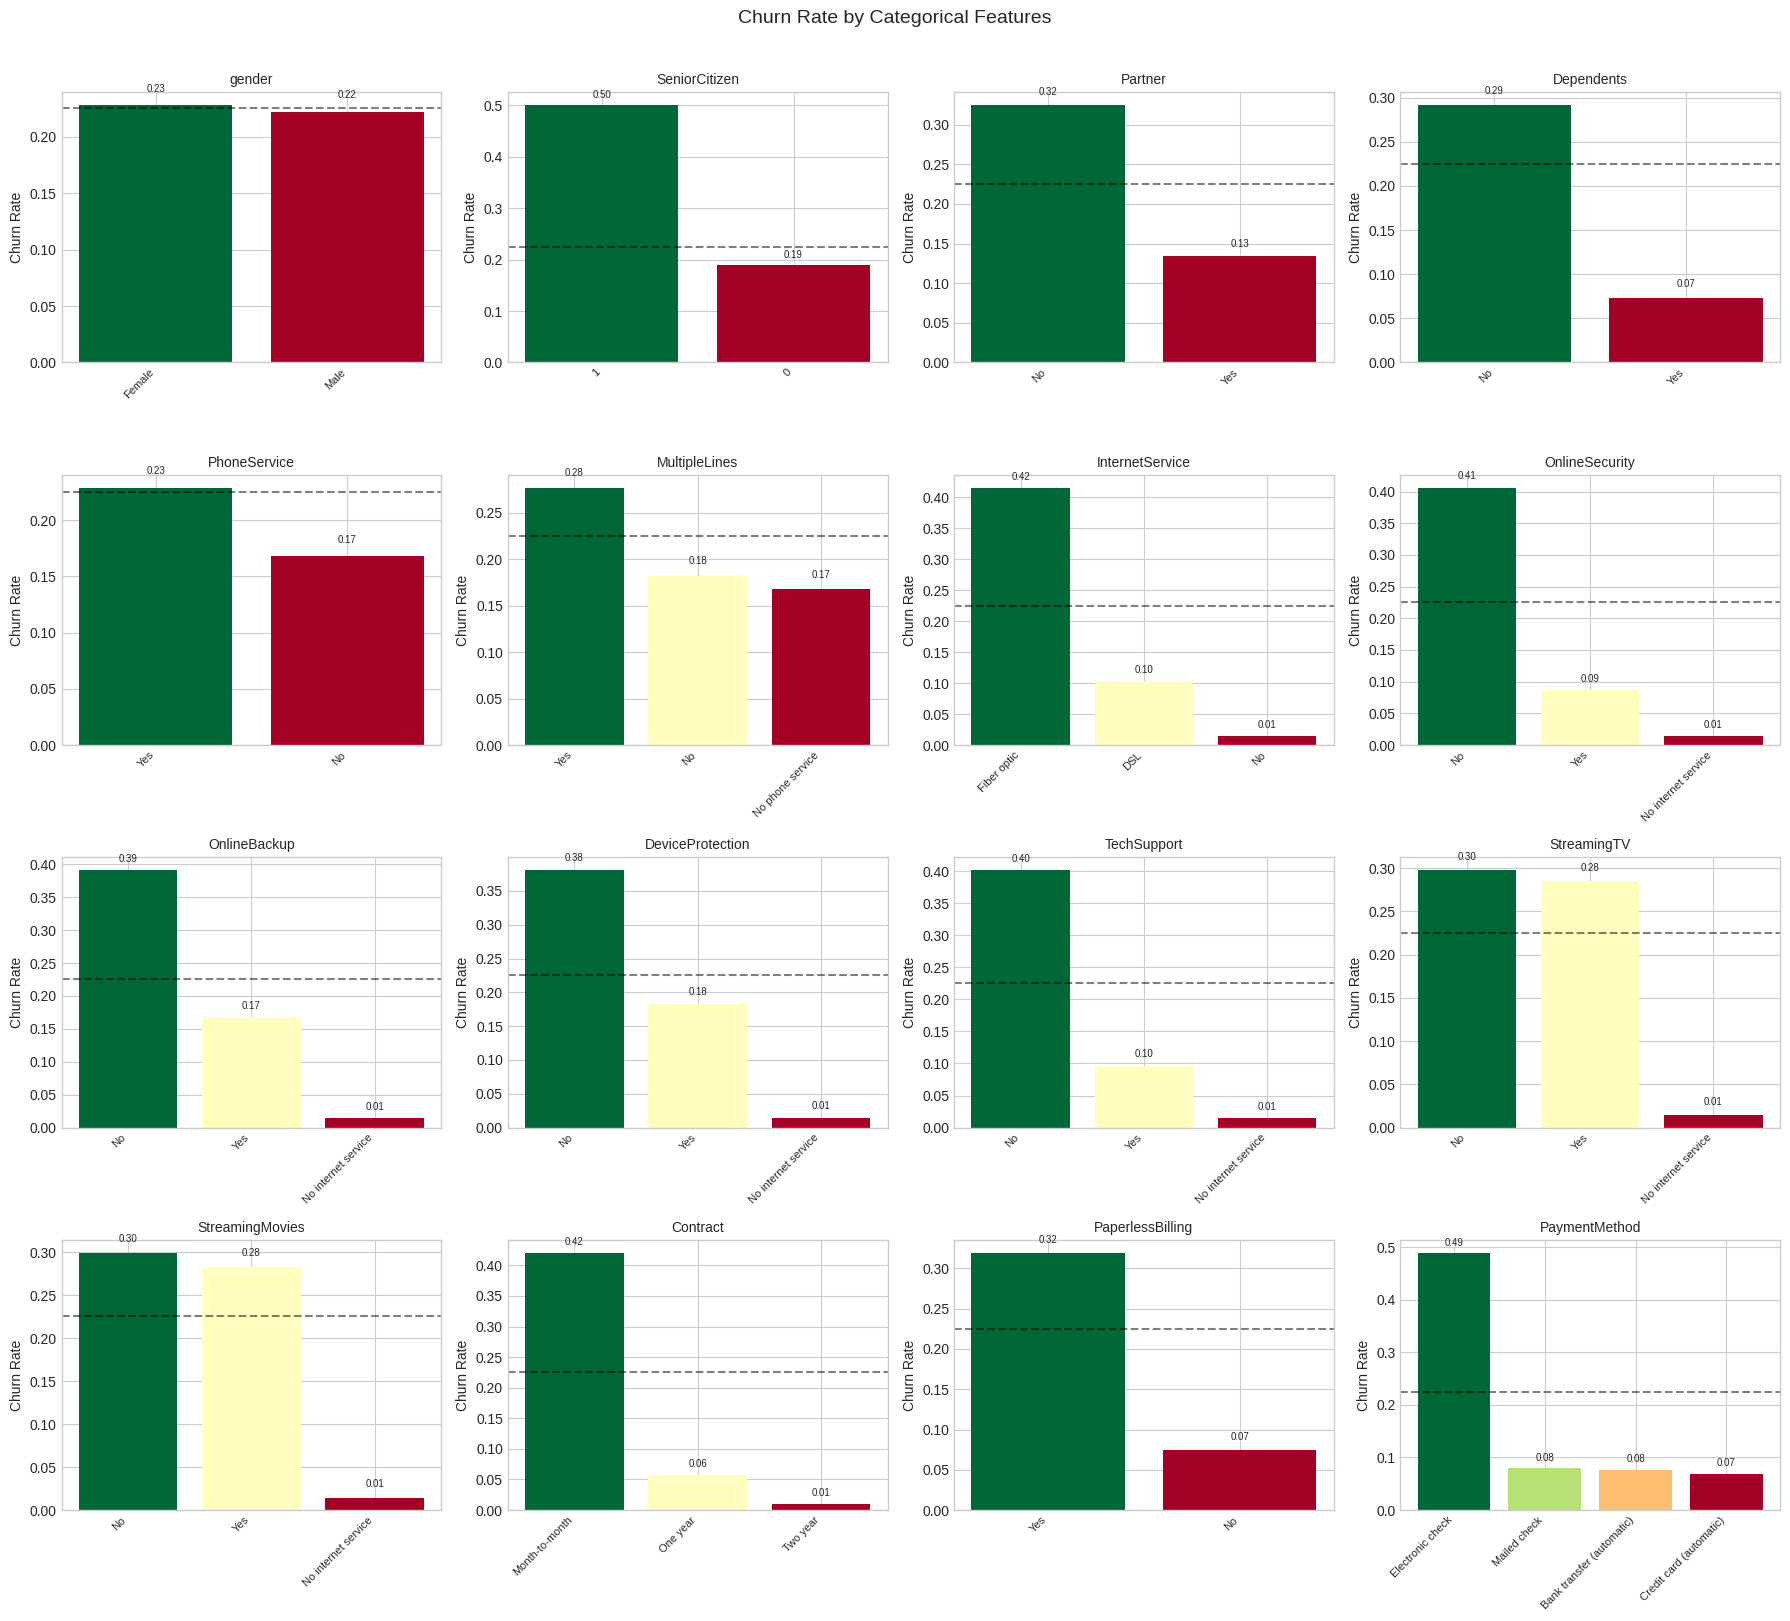

In [11]:
# Categorical Features Analysis
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for idx, col in enumerate(CATS):
    # Calculate churn rate by category
    churn_rate = train.groupby(col)[CFG.TARGET].mean().sort_values(ascending=False)

    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(churn_rate)))
    bars = axes[idx].bar(range(len(churn_rate)), churn_rate.values, color=colors)
    axes[idx].set_xticks(range(len(churn_rate)))
    axes[idx].set_xticklabels(churn_rate.index, rotation=45, ha='right', fontsize=8)
    axes[idx].set_ylabel('Churn Rate')
    axes[idx].set_title(f'{col}', fontsize=10)
    axes[idx].axhline(y=train[CFG.TARGET].mean(), color='black', linestyle='--', alpha=0.5)

    # Add value labels
    for bar, val in zip(bars, churn_rate.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                      f'{val:.2f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

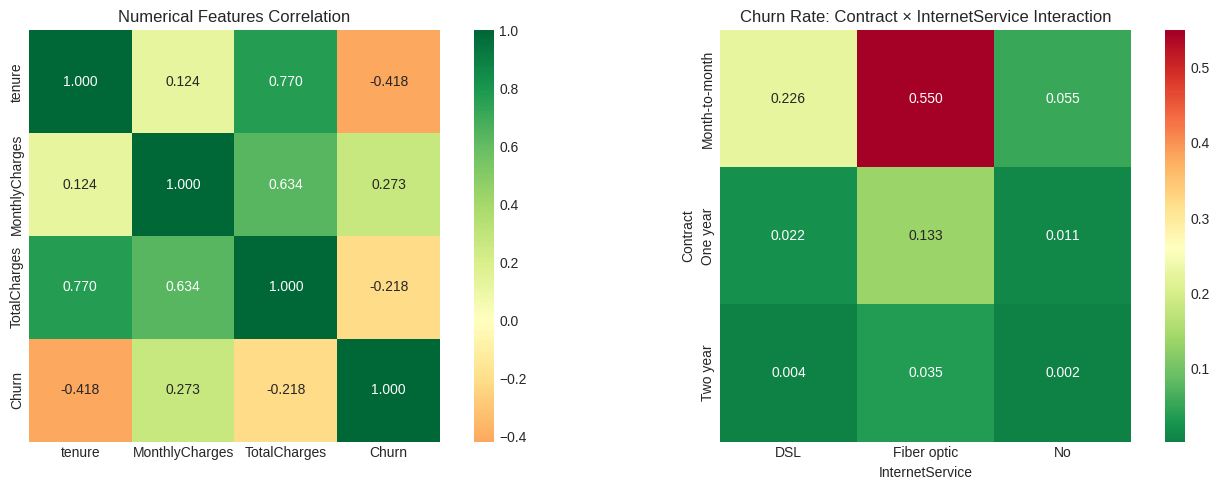


Note: Strong interaction between Contract type and InternetService!
This justifies using bi-gram/tri-gram composite features.


In [12]:
# Correlation Matrix for Numerical Features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Numerical correlation
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = train[num_cols + [CFG.TARGET]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, ax=axes[0],
            fmt='.3f', square=True)
axes[0].set_title('Numerical Features Correlation')

# Contract vs InternetService churn rates (important interaction)
pivot = train.pivot_table(values=CFG.TARGET, index='Contract',
                          columns='InternetService', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='RdYlGn_r', center=0.26, ax=axes[1],
            fmt='.3f', square=True)
axes[1].set_title('Churn Rate: Contract × InternetService Interaction')

plt.tight_layout()
plt.show()

print("\nNote: Strong interaction between Contract type and InternetService!")
print("This justifies using bi-gram/tri-gram composite features.")

## 4.Feature Engineering

### Arithmetic & Logical Features
We derived direct mathematical relationships from the base numerical columns (`tenure`, `MonthlyCharges`, `TotalCharges`):
* **`charges_deviation`**: Calculated as `TotalCharges - (tenure * MonthlyCharges)`. Measures the discrepancy between expected and actual total charges.
* **`monthly_to_total_ratio`**: Calculated as `MonthlyCharges / (TotalCharges + 1)`.
* **`avg_monthly_charges`**: Calculated as `TotalCharges / (tenure + 1)`.
* **`service_count`**: The sum of boolean flags for extra services (`OnlineSecurity`, `TechSupport`, `StreamingTV`, etc.).
* **`has_internet` & `has_phone`**: Binary indicators (1/0) checking if the customer has these base services.

### Statistical & Distribution Features
We measured how a customer compares to the rest of the dataset using safe reference populations:
* **`pctrank_global_TC`**: The percentile rank of a customer's `TotalCharges` against the entire dataset using `np.searchsorted`.
* **`resid_IS_MC`**: The difference between a customer's `MonthlyCharges` and the mean `MonthlyCharges` of their specific `InternetService` group.
* **Conditional Percentile Ranks**: `cond_pctrank_IS_TC` and `cond_pctrank_C_TC` calculate the rank of a customer's total charges specifically within their own Internet Service and Contract type groups.
* **Global Quantile Distances**: Absolute differences between a customer's `TotalCharges` and the global 25th, 50th, and 75th percentiles (`dist_To_global_q25`, etc.).

### Digit & Fractional Extraction
We extracted the granular components of numerical values (specifically tenure and charges) to capture psychological pricing tiers and system artifacts:
* **String Extractions**: First digit, last digit, and second digit of `tenure`, `MonthlyCharges`, and `TotalCharges`.
* **Modulo Operations**: `mod10`, `mod12` (for tenure), and `mod100` to find remainders and check for multiples of 10, 50, or 100.
* **Fractional & Deviations**: `mc_fractional` (the decimal part of the charge) and deviations from nearest rounded numbers (e.g., `tc_dev_from_round100`).

### N-Gram (Composite) Categorical Features
We used `itertools.combinations` to combine the most important categorical variables (based on feature importance) into new, complex categories:
* **Bi-grams (15 features)**: All 2-way combinations of the top 6 categories (e.g., `BG_Contract_InternetService`).
* **Tri-grams (4 features)**: All 3-way combinations of the top 4 categories (e.g., `TG_Contract_InternetService_PaymentMethod`).

### Inner-Fold Target Encoding
To convert categorical variables and our new N-Grams into numerical values without target leakage, we applied Target Encoding:
* **Categorical Stats**: Calculated `mean`, `std`, `min`, and `max` of the target for each category using a strict 5-Fold inner loop (`skf_inner`).
* **Smoothing**: Utilized `sklearn.preprocessing.TargetEncoder` with `smooth='auto'` to prevent overfitting on categories with very few samples.



In [13]:
# Define Feature Groups
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]
NUMS = ['tenure', 'MonthlyCharges', 'TotalCharges']

NEW_NUMS = []
NUM_AS_CAT = []

print("Feature Engineering Pipeline Started...")
print("="*60)

Feature Engineering Pipeline Started...


In [14]:
# 1. Frequency Encoding
print("[1/7] Creating Frequency Encoding features (Sadece Train+Test)...")
for col in NUMS:
    # orig yerine test'i ekleyerek global frekansı buluyoruz
    freq = pd.concat([train[col], test[col]]).value_counts(normalize=True)
    
    # orig veri setini döngüden çıkardık
    for df in [train, test]:
        df[f'FREQ_{col}'] = df[col].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{col}')
    
print(f"    Created {len(NUMS)} frequency features")

[1/7] Creating Frequency Encoding features (Sadece Train+Test)...
    Created 3 frequency features


In [15]:
# 2. Arithmetic Interactions
print("[2/7] Creating Arithmetic Interaction features...")
for df in [train, test]: # orig listeden çıkarıldı
    df['charges_deviation'] = (df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']).astype('float32')
    df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
    df['avg_monthly_charges'] = (df['TotalCharges'] / (df['tenure'] + 1)).astype('float32')
NEW_NUMS += ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']
print(f"    Created 3 arithmetic features")

[2/7] Creating Arithmetic Interaction features...
    Created 3 arithmetic features


In [16]:
# 3. Service Counts
print("[3/7] Creating Service Count features...")
SERVICE_COLS = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for df in [train, test]: # orig listeden çıkarıldı
    df['service_count'] = (df[SERVICE_COLS] == 'Yes').sum(axis=1).astype('float32')
    df['has_internet'] = (df['InternetService'] != 'No').astype('float32')
    df['has_phone'] = (df['PhoneService'] == 'Yes').astype('float32')
NEW_NUMS += ['service_count', 'has_internet', 'has_phone']
print(f"    Created 3 service count features")

[3/7] Creating Service Count features...
    Created 3 service count features


In [17]:
# 4. ORIG_proba Mapping (İPTAL EDİLDİ)
print("[4/7] ORIG_proba features İPTAL EDİLDİ! (Orijinal veri kullanılmıyor)...")

# Eski kodun tamamı silindi. NEW_NUMS listesine buradan hiçbir şey eklenmiyor.

[4/7] ORIG_proba features İPTAL EDİLDİ! (Orijinal veri kullanılmıyor)...


In [18]:
# 5. Distribution Features
print("[5/7] Creating Distribution Features (Safe global percentiles/residuals)...")

def pctrank_against(values, reference):
    ref_sorted = np.sort(reference)
    return (np.searchsorted(ref_sorted, values) / len(ref_sorted)).astype('float32')

def zscore_against(values, reference):
    mu, sigma = np.mean(reference), np.std(reference)
    return (np.zeros(len(values), dtype='float32') if sigma == 0
            else ((values - mu) / sigma).astype('float32'))

# GÜVENLİ REFERANS: Hedef sızıntısı yapmamak için sadece Train+Test birleşimi kullanılıyor
global_df = pd.concat([train, test], axis=0)
global_tc = global_df['TotalCharges'].values
global_is_mc_mean = global_df.groupby('InternetService')['MonthlyCharges'].mean()

for df in [train, test]:
    tc = df['TotalCharges'].values
    
    # 1. Genel Yüzdelik Dilim (Orijinal veri yerine Train+Test)
    df['pctrank_global_TC'] = pctrank_against(tc, global_tc)
    
    # 2. İnternet Servisine Göre Aylık Ücret Sapması
    df['resid_IS_MC'] = (df['MonthlyCharges'] - df['InternetService'].map(global_is_mc_mean).fillna(0)).astype('float32')

    # 3. İnternet Servisine Göre Şartlı Yüzdelik Dilim
    vals = np.zeros(len(df), dtype='float32')
    for cat_val in global_df['InternetService'].unique():
        mask = df['InternetService'] == cat_val
        ref = global_df.loc[global_df['InternetService'] == cat_val, 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df.loc[mask, 'TotalCharges'].values, ref)
    df['cond_pctrank_IS_TC'] = vals

    # 4. Kontrat Türüne Göre Şartlı Yüzdelik Dilim
    vals = np.zeros(len(df), dtype='float32')
    for cat_val in global_df['Contract'].unique():
        mask = df['Contract'] == cat_val
        ref = global_df.loc[global_df['Contract'] == cat_val, 'TotalCharges'].values
        if len(ref) > 0 and mask.sum() > 0:
            vals[mask] = pctrank_against(df.loc[mask, 'TotalCharges'].values, ref)
    df['cond_pctrank_C_TC'] = vals

DIST_FEATURES = [
    'pctrank_global_TC', 'resid_IS_MC', 'cond_pctrank_IS_TC', 'cond_pctrank_C_TC'
]
NEW_NUMS += DIST_FEATURES
print(f"    Created {len(DIST_FEATURES)} distribution features (Target-leaky ones removed)")

[5/7] Creating Distribution Features (Safe global percentiles/residuals)...
    Created 4 distribution features (Target-leaky ones removed)


In [19]:
# 6. Quantile Distance Features
print("[6/7] Creating Quantile Distance Features (Safe Global Quantiles)...")

# GÜVENLİ REFERANS: Tüm verinin (Train+Test birleşimi) TotalCharges değerleri
global_tc = pd.concat([train['TotalCharges'], test['TotalCharges']]).values

QDIST_FEATURES = []
for q_label, q_val in [('q25', 0.25), ('q50', 0.50), ('q75', 0.75)]:
    global_q = np.quantile(global_tc, q_val)
    for df in [train, test]:
        # Sadece genel çeyrekliklere olan uzaklık hesaplanıyor (Churn kopya çekmek yok)
        df[f'dist_To_global_{q_label}'] = np.abs(df['TotalCharges'] - global_q).astype('float32')
    QDIST_FEATURES.append(f'dist_To_global_{q_label}')

NEW_NUMS += QDIST_FEATURES
print(f"    Created {len(QDIST_FEATURES)} safe quantile distance features")

[6/7] Creating Quantile Distance Features (Safe Global Quantiles)...
    Created 3 safe quantile distance features


In [20]:
# 7. Numericals as Categories
print("[7/7] Creating Numericals-as-Categories features...")
for col in NUMS:
    _new = f'CAT_{col}'
    NUM_AS_CAT.append(_new)
    for df in [train, test]:
        df[_new] = df[col].astype(str).astype('category')
print(f"    Created {len(NUMS)} numerical-as-category features")

print("="*60)
print("🎯 FEATURE ENGINEERING (ÖZEL HİLELERDEN ARINDIRILMIŞ) TAMAMLANDI!")
print("="*60)

[7/7] Creating Numericals-as-Categories features...
    Created 3 numerical-as-category features
🎯 FEATURE ENGINEERING (ÖZEL HİLELERDEN ARINDIRILMIŞ) TAMAMLANDI!


In [21]:
# Digit Features
DIGIT_FEATURES = [
    # Tenure
    'tenure_first_digit','tenure_last_digit','tenure_second_digit',
    'tenure_mod10','tenure_mod12','tenure_num_digits',
    'tenure_is_multiple_10','tenure_rounded_10','tenure_dev_from_round10',

    # MonthlyCharges
    'mc_first_digit','mc_last_digit','mc_second_digit',
    'mc_mod10','mc_mod100','mc_num_digits',
    'mc_is_multiple_10','mc_is_multiple_50',
    'mc_rounded_10','mc_fractional','mc_dev_from_round10',

    # TotalCharges
    'tc_first_digit','tc_last_digit','tc_second_digit',
    'tc_mod10','tc_mod100','tc_num_digits',
    'tc_is_multiple_10','tc_is_multiple_100',
    'tc_rounded_100','tc_fractional','tc_dev_from_round100',

    # Derived
    'tenure_years','tenure_months_in_year',
    'mc_per_digit','tc_per_digit'
]

for df in [train, test]:

    # Tenure digits
    t_str = df['tenure'].astype(str)
    df['tenure_first_digit'] = t_str.str[0].astype(int)
    df['tenure_last_digit'] = t_str.str[-1].astype(int)
    df['tenure_second_digit'] = t_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['tenure_mod10'] = df['tenure'] % 10
    df['tenure_mod12'] = df['tenure'] % 12
    df['tenure_num_digits'] = t_str.str.len()

    df['tenure_is_multiple_10'] = (df['tenure'] % 10 == 0).astype('float32')

    df['tenure_rounded_10'] = np.round(df['tenure']/10)*10
    df['tenure_dev_from_round10'] = abs(df['tenure'] - df['tenure_rounded_10'])

    # MonthlyCharges
    mc_str = df['MonthlyCharges'].astype(str).str.replace('.', '')

    df['mc_first_digit'] = mc_str.str[0].astype(int)
    df['mc_last_digit'] = mc_str.str[-1].astype(int)
    df['mc_second_digit'] = mc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['mc_mod10'] = np.floor(df['MonthlyCharges']) % 10
    df['mc_mod100'] = np.floor(df['MonthlyCharges']) % 100

    df['mc_num_digits'] = np.floor(df['MonthlyCharges']).astype(int).astype(str).str.len()

    df['mc_is_multiple_10'] = (np.floor(df['MonthlyCharges']) % 10 == 0).astype('float32')
    df['mc_is_multiple_50'] = (np.floor(df['MonthlyCharges']) % 50 == 0).astype('float32')

    df['mc_rounded_10'] = np.round(df['MonthlyCharges']/10)*10
    df['mc_fractional'] = df['MonthlyCharges'] - np.floor(df['MonthlyCharges'])
    df['mc_dev_from_round10'] = abs(df['MonthlyCharges'] - df['mc_rounded_10'])

    # TotalCharges
    tc_str = df['TotalCharges'].astype(str).str.replace('.', '')

    df['tc_first_digit'] = tc_str.str[0].astype(int)
    df['tc_last_digit'] = tc_str.str[-1].astype(int)
    df['tc_second_digit'] = tc_str.apply(lambda x: int(x[1]) if len(x) > 1 else 0)

    df['tc_mod10'] = np.floor(df['TotalCharges']) % 10
    df['tc_mod100'] = np.floor(df['TotalCharges']) % 100

    df['tc_num_digits'] = np.floor(df['TotalCharges']).astype(int).astype(str).str.len()

    df['tc_is_multiple_10'] = (np.floor(df['TotalCharges']) % 10 == 0).astype('float32')
    df['tc_is_multiple_100'] = (np.floor(df['TotalCharges']) % 100 == 0).astype('float32')

    df['tc_rounded_100'] = np.round(df['TotalCharges']/100)*100
    df['tc_fractional'] = df['TotalCharges'] - np.floor(df['TotalCharges'])

    df['tc_dev_from_round100'] = abs(df['TotalCharges'] - df['tc_rounded_100'])

    # Derived
    df['tenure_years'] = df['tenure'] // 12
    df['tenure_months_in_year'] = df['tenure'] % 12

    df['mc_per_digit'] = df['MonthlyCharges']/(df['mc_num_digits']+0.001)
    df['tc_per_digit'] = df['TotalCharges']/(df['tc_num_digits']+0.001)

NEW_NUMS += DIGIT_FEATURES
print(f"    Created {len(DIGIT_FEATURES)} digit features")

    Created 35 digit features


In [22]:
# Create Bi-gram and Tri-gram Composite Categorical Features
print("\n" + "="*60)
print("Creating Bi-gram / Tri-gram Composite Features...")
print("="*60)

BIGRAM_COLS = []
TRIGRAM_COLS = []

# Bi-grams: all pairs from top 6 cats = C(6,2) = 15 pairs
print(f"\nCreating Bi-gram features from top {len(TOP_CATS_FOR_NGRAM)} categoricals:")
print(f"  Columns: {TOP_CATS_FOR_NGRAM}")
for c1, c2 in combinations(TOP_CATS_FOR_NGRAM, 2):
    col_name = f"BG_{c1}_{c2}"
    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str)).astype('category')
    BIGRAM_COLS.append(col_name)

print(f"  Created {len(BIGRAM_COLS)} bi-gram features")

# Tri-grams: top 4 cats only to limit = C(4,3) = 4 triples
TOP4 = TOP_CATS_FOR_NGRAM[:4]
print(f"\nCreating Tri-gram features from top 4 categoricals:")
print(f"  Columns: {TOP4}")
for c1, c2, c3 in combinations(TOP4, 3):
    col_name = f"TG_{c1}_{c2}_{c3}"
    for df in [train, test]:
        df[col_name] = (df[c1].astype(str) + "_" + df[c2].astype(str) + "_" + df[c3].astype(str)).astype('category')
    TRIGRAM_COLS.append(col_name)

print(f"  Created {len(TRIGRAM_COLS)} tri-gram features")

NGRAM_COLS = BIGRAM_COLS + TRIGRAM_COLS
print(f"\nTotal N-gram features: {len(NGRAM_COLS)}")


Creating Bi-gram / Tri-gram Composite Features...

Creating Bi-gram features from top 6 categoricals:
  Columns: ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']
  Created 15 bi-gram features

Creating Tri-gram features from top 4 categoricals:
  Columns: ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']
  Created 4 tri-gram features

Total N-gram features: 19


In [23]:
# Feature Summary
FEATURES = NUMS + CATS + NEW_NUMS + NUM_AS_CAT + NGRAM_COLS
TE_COLUMNS = NUM_AS_CAT + CATS
TE_NGRAM_COLUMNS = NGRAM_COLS
TO_REMOVE = NUM_AS_CAT + CATS + NGRAM_COLS
STATS = ['std', 'min', 'max']

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"Total Features: {len(FEATURES)}")
print(f"  - Numerical:            {len(NUMS)}")
print(f"  - Categorical:          {len(CATS)}")
print(f"  - Engineered Numerical: {len(NEW_NUMS)}")
print(f"  - Num-as-Cat:           {len(NUM_AS_CAT)}")
print(f"  - Bi-gram:              {len(BIGRAM_COLS)}")
print(f"  - Tri-gram:             {len(TRIGRAM_COLS)}")


FEATURE ENGINEERING COMPLETE
Total Features: 92
  - Numerical:            3
  - Categorical:          16
  - Engineered Numerical: 51
  - Num-as-Cat:           3
  - Bi-gram:              15
  - Tri-gram:             4


## 5.MultiStacking Model Training

In [24]:
from sklearn.ensemble import ExtraTreesClassifier
try:
    from cuml.neighbors import KNeighborsClassifier as cuKNN
    from cuml.svm import SVC as cuSVC
    from cuml.ensemble import RandomForestClassifier as cuRF
    print("RAPIDS cuML ACTİVE")
except ImportError:
    print("cuML not found")

print("\n" + "="*70)
print(f"SEVEN SAMURAİ: XGB + LGB + CAT + cuRF + cuKNN + cuSVM + RealMLP ({CFG.N_FOLDS}-FOLD)")
print("="*70)

np.random.seed(CFG.RANDOM_SEED)
skf_outer = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)
skf_inner = StratifiedKFold(n_splits=CFG.INNER_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)

ridge_oof, ridge_pred = np.zeros(len(train)), np.zeros(len(test))
xgb_oof, xgb_pred = np.zeros(len(train)), np.zeros(len(test))
lgb_oof, lgb_pred = np.zeros(len(train)), np.zeros(len(test))
cat_oof, cat_pred = np.zeros(len(train)), np.zeros(len(test))
rf_oof, rf_pred = np.zeros(len(train)), np.zeros(len(test))
knn_oof, knn_pred = np.zeros(len(train)), np.zeros(len(test))
svm_oof, svm_pred = np.zeros(len(train)), np.zeros(len(test))
mlp_oof, mlp_pred = np.zeros(len(train)), np.zeros(len(test))

t0_all = time.time()

for i, (train_idx, val_idx) in enumerate(skf_outer.split(train, train[CFG.TARGET])):
    t0_fold = time.time()
    print(f"\n{'='*50}\nFold {i+1}/{CFG.N_FOLDS}\n{'='*50}")

    X_tr  = train.loc[train_idx, FEATURES + [CFG.TARGET]].reset_index(drop=True).copy()
    y_tr  = train.loc[train_idx, CFG.TARGET].values
    X_val = train.loc[val_idx, FEATURES].reset_index(drop=True).copy()
    y_val = train.loc[val_idx, CFG.TARGET].values
    X_te  = test[FEATURES].reset_index(drop=True).copy()

    # Target Encoding 
    for j, (in_tr, in_va) in enumerate(skf_inner.split(X_tr, y_tr)):
        X_tr2, X_va2 = X_tr.loc[in_tr, FEATURES + [CFG.TARGET]].copy(), X_tr.loc[in_va, FEATURES].copy()
        for col in TE_COLUMNS:
            tmp = X_tr2.groupby(col, observed=False)[CFG.TARGET].agg(STATS)
            tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
            X_va2 = X_va2.merge(tmp, on=col, how="left")
            for c in tmp.columns: X_tr.loc[in_va, c] = X_va2[c].values.astype("float32")

    for col in TE_COLUMNS:
        tmp = X_tr.groupby(col, observed=False)[CFG.TARGET].agg(STATS)
        tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
        tmp = tmp.astype("float32")
        X_val, X_te = X_val.merge(tmp, on=col, how="left"), X_te.merge(tmp, on=col, how="left")
        for c in tmp.columns:
            for df in [X_tr, X_val, X_te]: df[c] = df[c].fillna(0)

    for j, (in_tr, in_va) in enumerate(skf_inner.split(X_tr, y_tr)):
        X_tr2, X_va2 = X_tr.loc[in_tr].copy(), X_tr.loc[in_va].copy()
        for col in TE_NGRAM_COLUMNS:
            ng_te = X_tr2.groupby(col, observed=False)[CFG.TARGET].mean()
            ng_name = f"TE_ng_{col}"
            X_tr.loc[in_va, ng_name] = pd.to_numeric(X_va2[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32').values

    for col in TE_NGRAM_COLUMNS:
        ng_te = X_tr.groupby(col, observed=False)[CFG.TARGET].mean()
        ng_name = f"TE_ng_{col}"
        X_val[ng_name] = pd.to_numeric(X_val[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32')
        X_te[ng_name]  = pd.to_numeric(X_te[col].astype(str).map(ng_te), errors='coerce').fillna(0.5).astype('float32')
        X_tr[ng_name] = pd.to_numeric(X_tr[ng_name], errors='coerce').fillna(0.5).astype('float32') if ng_name in X_tr.columns else 0.5

    TE_MEAN_COLS = [f'TE_{col}' for col in TE_COLUMNS]
    te = TargetEncoder(cv=CFG.INNER_FOLDS, shuffle=True, smooth='auto', target_type='binary', random_state=CFG.RANDOM_SEED)
    X_tr[TE_MEAN_COLS] = te.fit_transform(X_tr[TE_COLUMNS], y_tr)
    X_val[TE_MEAN_COLS], X_te[TE_MEAN_COLS] = te.transform(X_val[TE_COLUMNS]), te.transform(X_te[TE_COLUMNS])

    # STEP 1: RIDGE 
    print(f"  [1/8] Ridge Training...")
    ridge_numeric_features = NUMS + NEW_NUMS + DIGIT_FEATURES + [c for c in X_tr.columns if c.startswith('TE1_')] + [c for c in X_tr.columns if c.startswith('TE_ng_')] + TE_MEAN_COLS
    scaler = StandardScaler()
    X_tr_ridge_num = scaler.fit_transform(X_tr[ridge_numeric_features].fillna(0))
    X_val_ridge_num = scaler.transform(X_val[ridge_numeric_features].fillna(0))
    X_te_ridge_num = scaler.transform(X_te[ridge_numeric_features].fillna(0))

    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    X_tr_ridge_cat = ohe.fit_transform(X_tr[CATS].astype(str))
    X_val_ridge_cat = ohe.transform(X_val[CATS].astype(str))
    X_te_ridge_cat = ohe.transform(X_te[CATS].astype(str))

    X_tr_ridge = sparse.hstack([X_tr_ridge_num, X_tr_ridge_cat]).tocsr()
    X_val_ridge = sparse.hstack([X_val_ridge_num, X_val_ridge_cat]).tocsr()
    X_te_ridge = sparse.hstack([X_te_ridge_num, X_te_ridge_cat]).tocsr()

    ridge = Ridge(alpha=CFG.RIDGE_ALPHA, random_state=CFG.RANDOM_SEED)
    ridge.fit(X_tr_ridge, y_tr)
    ridge_tr_pred = np.clip(ridge.predict(X_tr_ridge), 0, 1)
    ridge_val_pred = np.clip(ridge.predict(X_val_ridge), 0, 1)
    ridge_te_pred = np.clip(ridge.predict(X_te_ridge), 0, 1)
    
    # DATA PREPARATION FOR TREE MODELS
    X_tr_tree, X_val_tree, X_te_tree = X_tr.copy(), X_val.copy(), X_te.copy()
    X_tr_tree['ridge_pred'], X_val_tree['ridge_pred'], X_te_tree['ridge_pred'] = ridge_tr_pred.astype('float32'), ridge_val_pred.astype('float32'), ridge_te_pred.astype('float32')

    for df in [X_tr_tree, X_val_tree, X_te_tree]:
        for c in CATS + NUM_AS_CAT:
            if c in df.columns:
                df[c] = df[c].astype(str).fillna('missing').astype("category")
        df.drop(columns=[c for c in TO_REMOVE if c in df.columns], inplace=True, errors='ignore')
    X_tr_tree.drop(columns=[CFG.TARGET], inplace=True, errors='ignore')
    valid_cats = [c for c in CATS + NUM_AS_CAT if c in X_tr_tree.columns]

    # STEP 2: XGBOOST 
    print(f"  [2/8] XGBoost Training...")
    model_xgb = xgb.XGBClassifier(**XGB_PARAMS)
    model_xgb.fit(X_tr_tree, y_tr, eval_set=[(X_val_tree, y_val)], verbose=False)
    xgb_oof[val_idx] = model_xgb.predict_proba(X_val_tree)[:, 1]
    xgb_pred += model_xgb.predict_proba(X_te_tree)[:, 1] / CFG.N_FOLDS

    # STEP 3: LIGHTGBM  
    print(f"  [3/8] LightGBM Training...")
    X_tr_lgb, X_val_lgb, X_te_lgb = X_tr_tree.copy(), X_val_tree.copy(), X_te_tree.copy()
    for c in X_tr_lgb.select_dtypes(include=['category']).columns:
        X_tr_lgb[c] = X_tr_lgb[c].cat.codes.astype('int32')
        X_val_lgb[c] = X_val_lgb[c].cat.codes.astype('int32')
        X_te_lgb[c] = X_te_lgb[c].cat.codes.astype('int32')

    model_lgb = lgb.LGBMClassifier(**LGB_PARAMS)
    callbacks_lgb = [lgb.early_stopping(stopping_rounds=100, verbose=False)]
    model_lgb.fit(X_tr_lgb, y_tr, eval_set=[(X_val_lgb, y_val)], callbacks=callbacks_lgb)
    lgb_oof[val_idx] = model_lgb.predict_proba(X_val_lgb)[:, 1]
    lgb_pred += model_lgb.predict_proba(X_te_lgb)[:, 1] / CFG.N_FOLDS

    # STEP 4: CATBOOST 
    print(f"  [4/8] CatBoost Training...")
    model_cat = CatBoostClassifier(**CAT_PARAMS)
    model_cat.fit(X_tr_tree, y_tr, eval_set=(X_val_tree, y_val), cat_features=valid_cats, early_stopping_rounds=100, verbose=False)
    cat_oof[val_idx] = model_cat.predict_proba(X_val_tree)[:, 1]
    cat_pred += model_cat.predict_proba(X_te_tree)[:, 1] / CFG.N_FOLDS

    X_tr_dense = X_tr_ridge.toarray().astype('float32')
    X_val_dense = X_val_ridge.toarray().astype('float32')
    X_te_dense = X_te_ridge.toarray().astype('float32')

    # STEP 5: RANDOM FOREST (cuML GPU)
    print(f"  [5/8] Random Forest Training (cuML GPU)...")
    model_rf = cuRF(n_estimators=500, max_depth=12, random_state=CFG.RANDOM_SEED)
    model_rf.fit(X_tr_dense, y_tr)
    rf_oof_p = model_rf.predict_proba(X_val_dense)
    rf_oof[val_idx] = rf_oof_p[1] if isinstance(rf_oof_p, tuple) else rf_oof_p[:, 1]
    rf_te_p = model_rf.predict_proba(X_te_dense)
    rf_pred += (rf_te_p[1] if isinstance(rf_te_p, tuple) else rf_te_p[:, 1]) / CFG.N_FOLDS

    # STEP 6: KNN (cuML GPU)
    print(f"  [6/8] KNN Training (cuML GPU)...")
    model_knn = cuKNN(n_neighbors=128) 
    model_knn.fit(X_tr_dense, y_tr)
    knn_oof[val_idx] = model_knn.predict_proba(X_val_dense)[:, 1]
    knn_pred += model_knn.predict_proba(X_te_dense)[:, 1] / CFG.N_FOLDS

    # ─── AŞAMA 7: SVM (cuML GPU) 
    print(f"  [7/8] SVM Training (cuML GPU)...")
    model_svm = cuSVC(kernel='rbf', C=0.1, probability=True)
    model_svm.fit(X_tr_dense, y_tr)
    svm_oof[val_idx] = model_svm.predict_proba(X_val_dense)[:, 1]
    svm_pred += model_svm.predict_proba(X_te_dense)[:, 1] / CFG.N_FOLDS

    # SETP 8: REAL-MLP (PYTORCH GPU)
    print(f"  [8/8] RealMLP Training (PyTorch GPU)...")
    t_X_tr = torch.FloatTensor(X_tr_dense).to(device)
    t_y_tr = torch.FloatTensor(y_tr).to(device)
    t_X_val = torch.FloatTensor(X_val_dense).to(device)
    t_X_te = torch.FloatTensor(X_te_dense).to(device)
    
    model_mlp = RealMLP(input_dim=t_X_tr.shape[1]).to(device)
    criterion = torch.nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model_mlp.parameters(), lr=0.005, weight_decay=1e-4)
    
    best_val_auc, best_mlp_preds, best_mlp_te_preds, patience_counter = 0, None, None, 0
    for epoch in range(EPOCHS):
        model_mlp.train()
        optimizer.zero_grad()
        loss = criterion(model_mlp(t_X_tr), t_y_tr)
        loss.backward()
        optimizer.step()
        
        model_mlp.eval()
        with torch.no_grad():
            val_preds = torch.sigmoid(model_mlp(t_X_val)).cpu().numpy()
            v_auc = roc_auc_score(y_val, val_preds)
            if v_auc > best_val_auc:
                best_val_auc, best_mlp_preds = v_auc, val_preds
                best_mlp_te_preds = torch.sigmoid(model_mlp(t_X_te)).cpu().numpy()
                patience_counter = 0
            else:
                patience_counter += 1
        if patience_counter >= PATIENCE: break
            
    mlp_oof[val_idx] = best_mlp_preds
    mlp_pred += best_mlp_te_preds / CFG.N_FOLDS

    print(f"\n Fold {i+1} OOF Scores:")
    print(f"  Ridge  : {roc_auc_score(y_val, ridge_val_pred):.5f}")
    print(f"  XGBoost: {roc_auc_score(y_val, xgb_oof[val_idx]):.5f} | LightGBM: {roc_auc_score(y_val, lgb_oof[val_idx]):.5f} | CatBoost: {roc_auc_score(y_val, cat_oof[val_idx]):.5f}")
    print(f"  cuRF   : {roc_auc_score(y_val, rf_oof[val_idx]):.5f} | cuKNN   : {roc_auc_score(y_val, knn_oof[val_idx]):.5f} | cuSVM   : {roc_auc_score(y_val, svm_oof[val_idx]):.5f}")
    print(f"  RealMLP: {roc_auc_score(y_val, mlp_oof[val_idx]):.5f}")
    
    print(f"  Time: {(time.time()-t0_fold)/60:.1f} minute")
    del X_tr, X_val, X_te, X_tr_tree, X_val_tree, X_te_tree, X_tr_lgb, X_val_lgb, X_te_lgb
    del X_tr_dense, X_val_dense, X_te_dense
    gc.collect()

print(f"\n{'='*70}\nALL ROUNDS COMPLETED - OOF SCORES\n{'='*70}")

print("Predictions (OOF and Preds) are saved to disk as .npy files...")

np.save('xgb_oof.npy', xgb_oof)
np.save('lgb_oof.npy', lgb_oof)
np.save('cat_oof.npy', cat_oof)
np.save('rf_oof.npy', rf_oof)
np.save('knn_oof.npy', knn_oof)
np.save('svm_oof.npy', svm_oof)
np.save('mlp_oof.npy', mlp_oof)

np.save('xgb_pred.npy', xgb_pred)
np.save('lgb_pred.npy', lgb_pred)
np.save('cat_pred.npy', cat_pred)
np.save('rf_pred.npy', rf_pred)
np.save('knn_pred.npy', knn_pred)
np.save('svm_pred.npy', svm_pred)
np.save('mlp_pred.npy', mlp_pred)

print("All predictions have been successfully saved!")

y_all = train[CFG.TARGET].values
print(f"  XGBoost: {roc_auc_score(y_all, xgb_oof):.5f} | LightGBM: {roc_auc_score(y_all, lgb_oof):.5f} | CatBoost: {roc_auc_score(y_all, cat_oof):.5f}")
print(f"  cuRF   : {roc_auc_score(y_all, rf_oof):.5f} | cuKNN   : {roc_auc_score(y_all, knn_oof):.5f} | cuSVM   : {roc_auc_score(y_all, svm_oof):.5f}")
print(f"  RealMLP: {roc_auc_score(y_all, mlp_oof):.5f}")

RAPIDS cuML ACTİVE

SEVEN SAMURAİ: XGB + LGB + CAT + cuRF + cuKNN + cuSVM + RealMLP (20-FOLD)

Fold 1/20
  [1/8] Ridge Training...
  [2/8] XGBoost Training...
  [3/8] LightGBM Training...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  [4/8] CatBoost Training...


Default metric period is 5 because AUC is/are not implemented for GPU


  [5/8] Random Forest Training (cuML GPU)...
  [6/8] KNN Training (cuML GPU)...
  [7/8] SVM Training (cuML GPU)...
  [8/8] RealMLP Training (PyTorch GPU)...

 Fold 1 OOF Scores:
  Ridge  : 0.91127
  XGBoost: 0.92053 | LightGBM: 0.91976 | CatBoost: 0.91897
  cuRF   : 0.91696 | cuKNN   : 0.91232 | cuSVM   : 0.86010
  RealMLP: 0.91719
  Time: 13.2 minute

Fold 2/20
  [1/8] Ridge Training...
  [2/8] XGBoost Training...
  [3/8] LightGBM Training...
  [4/8] CatBoost Training...


...

  [5/8] Random Forest Training (cuML GPU)...
  [6/8] KNN Training (cuML GPU)...
  [7/8] SVM Training (cuML GPU)...
  [8/8] RealMLP Training (PyTorch GPU)...

 Fold 18 OOF Scores:
  Ridge  : 0.90923
  XGBoost: 0.91802 | LightGBM: 0.91770 | CatBoost: 0.91703
  cuRF   : 0.91501 | cuKNN   : 0.91074 | cuSVM   : 0.86269
  RealMLP: 0.91518
  Time: 12.1 minute

Fold 19/20
  [1/8] Ridge Training...
  [2/8] XGBoost Training...
  [3/8] LightGBM Training...
  [4/8] CatBoost Training...


Default metric period is 5 because AUC is/are not implemented for GPU


  [5/8] Random Forest Training (cuML GPU)...
  [6/8] KNN Training (cuML GPU)...
  [7/8] SVM Training (cuML GPU)...
  [8/8] RealMLP Training (PyTorch GPU)...

 Fold 19 OOF Scores:
  Ridge  : 0.91035
  XGBoost: 0.91839 | LightGBM: 0.91789 | CatBoost: 0.91730
  cuRF   : 0.91498 | cuKNN   : 0.91142 | cuSVM   : 0.86109
  RealMLP: 0.91579
  Time: 12.3 minute

Fold 20/20
  [1/8] Ridge Training...
  [2/8] XGBoost Training...
  [3/8] LightGBM Training...
  [4/8] CatBoost Training...


Default metric period is 5 because AUC is/are not implemented for GPU


  [5/8] Random Forest Training (cuML GPU)...
  [6/8] KNN Training (cuML GPU)...
  [7/8] SVM Training (cuML GPU)...
  [8/8] RealMLP Training (PyTorch GPU)...

 Fold 20 OOF Scores:
  Ridge  : 0.90674
  XGBoost: 0.91556 | LightGBM: 0.91530 | CatBoost: 0.91436
  cuRF   : 0.91183 | cuKNN   : 0.90655 | cuSVM   : 0.85485
  RealMLP: 0.91256
  Time: 12.2 minute

ALL ROUNDS COMPLETED - OOF SCORES
Predictions (OOF and Preds) are saved to disk as .npy files...
All predictions have been successfully saved!
  XGBoost: 0.91920 | LightGBM: 0.91876 | CatBoost: 0.91801
  cuRF   : 0.91577 | cuKNN   : 0.91122 | cuSVM   : 0.86181
  RealMLP: 0.91643


In [25]:
# GPU HILL CLIMBING ENSEMBLE (AUC, USE RANKS)
import os
import gc
import numpy as np
import pandas as pd
import cupy as cp
from sklearn.metrics import roc_auc_score
from scipy.stats import rankdata

BASE_PATH = '/kaggle/working/'


if BASE_PATH == '':
    raise FileNotFoundError("ERROR: .npy files with the number 7 could not be found!")
print(f"Files are being retrieved from this folder: {BASE_PATH}")

# CONFIG
TRAIN_CSV  = "/kaggle/input/competitions/playground-series-s6e3/train.csv"
TEST_CSV   = "/kaggle/input/competitions/playground-series-s6e3/test.csv"
TARGET_COL = "Churn"
ID_COL     = "id"
VER        = 7

# Optional: force starting model by name, else use best single
FIRST = None
USE_NEGATIVE_WGT = True
MAX_MODELS = 100
TOL = 1e-6  
start = -0.50 if USE_NEGATIVE_WGT else 0.01
stop  =  0.50
step  =  0.01

SUBMISSION_PATH = f"submission_hillclimb_v{VER}.csv"
WEIGHTS_PATH    = f"ensemble_weights_v{VER}.csv"

# YOUR MODELS 
FILES = [
    ("XGBoost",  BASE_PATH + "xgb_oof.npy"),
    ("LightGBM", BASE_PATH + "lgb_oof.npy"),
    ("CatBoost", BASE_PATH + "cat_oof.npy"),
    ("cuRF",     BASE_PATH + "rf_oof.npy"),
    ("cuKNN",    BASE_PATH + "knn_oof.npy"),
    ("cuSVM",    BASE_PATH + "svm_oof.npy"),
    ("RealMLP",  BASE_PATH + "mlp_oof.npy"),
]

# HELPERS
def to_binary_y(df, col):
    y = df[col]
    if y.dtype == "object" or str(y.dtype).startswith("string"):
        y = y.map({"No": 0, "Yes": 1})
    y = pd.to_numeric(y, errors="coerce")
    if y.isna().any():
        raise ValueError(f"Could not parse target column '{col}' to binary.")
    y = y.astype(np.int32).to_numpy()
    return y

def auc_cpu(y_true, y_pred):
    return float(roc_auc_score(y_true, y_pred))

def rank01(x):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    r = rankdata(x, method="average")
    if len(r) == 1:
        return np.array([0.5], dtype=np.float64)
    return (r - 1.0) / (len(r) - 1.0)

def derive_test_path(oof_path):
    cand1 = oof_path.replace("oof", "pred", 1)
    cand2 = oof_path.replace("oof", "test", 1)
    if os.path.exists(cand1):
        return cand1
    if os.path.exists(cand2):
        return cand2
    raise FileNotFoundError(f"Could not find pred/test file for: {oof_path}")

def load_preds_1d(path, expected_len, csv_col=TARGET_COL):
    if path.endswith(".csv"):
        df = pd.read_csv(path)
        if csv_col not in df.columns:
            raise ValueError(f"{path} missing column '{csv_col}'")
        arr = df[csv_col].to_numpy()
    else:
        arr = np.load(path)

    arr = np.asarray(arr, dtype=np.float64)

    if arr.ndim == 2:
        if arr.shape[1] == 1:
            arr = arr[:, 0]
        elif arr.shape[0] == expected_len:
            arr = arr.mean(axis=1)
        else:
            raise ValueError(f"Unexpected shape for {path}: {arr.shape}")

    arr = arr.reshape(-1)

    if len(arr) != expected_len:
        raise ValueError(f"Length mismatch for {path}: got {len(arr)}, expected {expected_len}")

    return arr

def multiple_roc_auc_scores(y_gpu, preds_gpu):
    """
    Fast approximate AUC on GPU for many candidate columns at once.
    Ties are approximate, which is okay for hill-climbing search.
    """
    n_pos = cp.sum(y_gpu)
    n_neg = y_gpu.size - n_pos
    ranks = cp.argsort(cp.argsort(preds_gpu, axis=0), axis=0) + 1
    aucs = (cp.sum(ranks[y_gpu == 1, :], axis=0) - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return aucs

# 1) LOAD DATA
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
y = to_binary_y(train, TARGET_COL)
N = len(train)
M = len(test)
print(f"Train rows: {N:,} | Pos rate: {y.mean():.6f}")
print(f"Test rows : {M:,}")

# 2) LOAD OOF / TEST PREDICTIONS
names = []
x_train = []
x_test = []

print("\nLoading predictions...")
for name, oof_path in FILES:
    test_path = derive_test_path(oof_path)

    oof = load_preds_1d(oof_path, N)
    pred = load_preds_1d(test_path, M)

    oof = rank01(oof)
    pred = rank01(pred)

    names.append(name)
    x_train.append(oof)
    x_test.append(pred)

    print(f"{name:18s} | OOF: Loaded | PRED: Loaded")

x_train = np.column_stack(x_train)
x_test  = np.column_stack(x_test)
print("\nOOF matrix :", x_train.shape)
print("TEST matrix:", x_test.shape)

# 3) SINGLE MODEL AUC
print("\nSingle-model AUC:")
single_aucs = []
for k, name in enumerate(names):
    s = auc_cpu(y, x_train[:, k])
    single_aucs.append(s)
    print(f"{name:18s} AUC = {s:.6f}")

best_idx = int(np.argmax(single_aucs))
best_auc = float(single_aucs[best_idx])
print(f"\nBest single: {names[best_idx]} (AUC={best_auc:.6f})")

# 4) START MODEL
if FIRST is None:
    start_idx = best_idx
else:
    if FIRST not in names:
        raise ValueError(f"FIRST='{FIRST}' not found in model list.")
    start_idx = names.index(FIRST)

start_auc = auc_cpu(y, x_train[:, start_idx])
print(f"Starting from: {names[start_idx]} (AUC={start_auc:.6f})")

# 5) PREP GPU
x_gpu = cp.asarray(x_train, dtype=cp.float32)
y_gpu = cp.asarray(y, dtype=cp.int8)
ww = cp.arange(start, stop + 1e-9, step, dtype=cp.float32)

best_ensemble = x_gpu[:, start_idx].copy()
best_score = float(start_auc)
models = [start_idx]
weights_step = []

# 6) HILL CLIMB
print("\nStarting hill climb...\n")
for it in range(1_000_000):
    if len(set(models)) >= MAX_MODELS:
        print(f"Reached MAX_MODELS={MAX_MODELS}")
        break

    base = best_ensemble[:, None] * (1.0 - ww)[None, :]

    best_it_score = -1.0
    best_it_idx = -1
    best_it_w = None
    best_it_ens = None

    for k in range(len(names)):
        cand = base + x_gpu[:, k][:, None] * ww[None, :]
        aucs = multiple_roc_auc_scores(y_gpu, cand)

        j = int(cp.argmax(aucs).item())
        s = float(aucs[j].item())

        if s > best_it_score:
            best_it_score = s
            best_it_idx = k
            best_it_w = float(ww[j].item())
            best_it_ens = cand[:, j]

        del cand, aucs

    improve = best_it_score - best_score
    if improve < TOL:
        print(f"Stopped: improvement {improve:.8f} < TOL={TOL}")
        break

    print(f"{it:3d}  AUC {best_it_score:.6f} | add {names[best_it_idx]:12s} | w = {best_it_w:.3f}")

    models.append(best_it_idx)
    weights_step.append(best_it_w)
    best_ensemble = best_it_ens
    best_score = best_it_score

    del base
    gc.collect()
    cp.get_default_memory_pool().free_all_blocks()

# 7) FINAL EXACT OOF AUC
final_oof = best_ensemble.get()
final_auc = auc_cpu(y, final_oof)
print(f"\nFinal OOF AUC (exact CPU): {final_auc:.6f}")

# 8) STEP WEIGHTS -> EFFECTIVE WEIGHTS
wgt = np.array([1.0], dtype=np.float64)
for w in weights_step:
    wgt = wgt * (1.0 - w)
    wgt = np.append(wgt, w)

dfw = (
    pd.DataFrame({
        "model": [names[m] for m in models],
        "weight": wgt
    })
    .groupby("model", as_index=False)["weight"].sum()
    .sort_values("weight", ascending=False)
    .reset_index(drop=True)
)
print("\nFinal weights:")
print(dfw.to_string(index=False))
print("\nWeight sum:", dfw["weight"].sum())
dfw.to_csv(WEIGHTS_PATH, index=False)
print(f"Saved weights: {WEIGHTS_PATH}")

# 9) SANITY CHECK OOF
blend_oof = np.zeros(N, dtype=np.float64)
for _, row in dfw.iterrows():
    k = names.index(row["model"])
    blend_oof += x_train[:, k] * float(row["weight"])
print(f"Sanity OOF AUC (exact CPU): {auc_cpu(y, blend_oof):.6f}")

# 10) TEST BLEND + SUBMISSION
blend_test = np.zeros(M, dtype=np.float64)
for _, row in dfw.iterrows():
    k = names.index(row["model"])
    blend_test += x_test[:, k] * float(row["weight"])

if ID_COL in test.columns:
    sub = pd.DataFrame({ID_COL: test[ID_COL].values, TARGET_COL: blend_test})
else:
    sub = pd.DataFrame({TARGET_COL: blend_test})
sub.to_csv(SUBMISSION_PATH, index=False)
print(f"\n✅ Saved submission: {SUBMISSION_PATH}")

Files are being retrieved from this folder: /kaggle/working/
Train rows: 594,194 | Pos rate: 0.225208
Test rows : 254,655

Loading predictions...
XGBoost            | OOF: Loaded | PRED: Loaded
LightGBM           | OOF: Loaded | PRED: Loaded
CatBoost           | OOF: Loaded | PRED: Loaded
cuRF               | OOF: Loaded | PRED: Loaded
cuKNN              | OOF: Loaded | PRED: Loaded
cuSVM              | OOF: Loaded | PRED: Loaded
RealMLP            | OOF: Loaded | PRED: Loaded

OOF matrix : (594194, 7)
TEST matrix: (254655, 7)

Single-model AUC:
XGBoost            AUC = 0.919202
LightGBM           AUC = 0.918763
CatBoost           AUC = 0.918011
cuRF               AUC = 0.915768
cuKNN              AUC = 0.911225
cuSVM              AUC = 0.861813
RealMLP            AUC = 0.916430

Best single: XGBoost (AUC=0.919202)
Starting from: XGBoost (AUC=0.919202)

Starting hill climb...

  0  AUC 0.919208 | add LightGBM     | w = 0.100
  1  AUC 0.919209 | add CatBoost     | w = 0.030
Stopped: imp

## 8. Future Improvements & Next Steps

While this pipeline achieves highly competitive results through the Two-Stage Ridge-to-Tree architecture and Hill Climbing ensemble, machine learning is a continuous iterative process. Here are a few advanced strategies that could push the AUC score even closer to the theoretical limit:

### A. Pseudo-Labeling (Semi-Supervised Learning)
Since we have a highly robust and confident ensemble, we could extract the test set predictions with extreme probabilities (e.g., $>0.95$ and $<0.05$). By treating these high-confidence predictions as "ground truth" labels and appending them to our training set, we could give our models extra data to solidify their decision boundaries.

### B. Feature Pruning via SHAP (Null Importance)
We generated a vast array of complex N-Gram, distribution, and digit features. While tree-based models generally handle wide datasets well, eliminating "noisy" features almost always prevents overfitting. Conducting a SHAP (SHapley Additive exPlanations) or Null-Importance analysis to prune the bottom 10-15% of features could streamline the pipeline and slightly boost the OOF CV score.

### C. Advanced Tabular Deep Learning
We successfully integrated `RealMLP` using PyTorch to capture non-tree-based patterns. In future iterations, exploring other state-of-the-art tabular neural networks like **TabNet** (which utilizes sequential attention) or **FT-Transformer** could add even more mathematical diversity to the ensemble.


